In [1]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
from sklearn import model_selection, metrics
from sklearn.metrics import (
    roc_curve, 
    roc_auc_score, 
    precision_recall_curve, 
    average_precision_score
)
from sklearn.linear_model import LogisticRegression

from mics import qrisk3, simulation

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
# Start small for a fast iteration, the scale up to 100k patients once the pipeline runs cleanly
n_patients = 100000
random_seed = 42

In [ ]:
# Generate population
patients = simulation.generate_patients(n_patients, random_seed=random_seed)
display(patients)

Age,Sex,Ethnicity,Townsend_Score,BMI,Systolic_Blood_Pressure,SD_Systolic_Blood_Pressure,Cholesterol_HDL_Ratio,Smoking Status,Type 1 Diabetes,Type 2 Diabetes,SLE,Severe Mental Illness,CKD,Atrial_Fibrillation,Rheumatoid_Arthritis,Migraine,Erectile_Disfunction,Corticosteroids,Atypical_Antipsychotics,Treated Hypertension,Family History of CVD
i64,str,str,f64,f64,f64,f64,f64,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
71,"""Female""","""White""",-0.987694,24.63,142.98,7.13,3.95,"""Non-Smoker""",0,0,0,0,0,0,0,0,0,0,0,1,1
34,"""Female""","""White""",-2.327794,28.4,137.69,2.8,3.67,"""Ex Smoker""",0,0,0,0,1,0,0,1,0,0,0,0,1
80,"""Male""","""White""",-0.059127,29.22,113.86,3.69,4.79,"""Non-Smoker""",0,0,0,1,1,0,0,0,1,0,0,0,0
40,"""Female""","""White""",-4.735652,21.43,148.35,1.51,3.21,"""Ex Smoker""",0,0,0,0,0,0,0,0,0,0,0,0,0
43,"""Male""","""White""",-0.700177,26.67,116.94,1.9,3.37,"""Non-Smoker""",0,0,0,0,0,0,0,0,0,0,0,0,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
50,"""Female""","""White""",-2.13341,26.67,139.58,2.2,3.49,"""Non-Smoker""",0,0,0,0,0,0,0,0,0,0,0,0,0
79,"""Male""","""White""",-2.128483,27.37,141.1,2.63,3.89,"""Ex Smoker""",0,0,0,0,0,0,0,0,1,0,0,0,1
62,"""Female""","""White""",7.744626,25.42,143.15,7.45,4.54,"""Non-Smoker""",0,0,0,0,0,0,0,1,0,0,0,0,1


# 

In [ ]:
# Prevelance of Type 2 diabetes in patients over 60 should be ~ 12%, rising with BMI 
patients.filter(
    pl.col("Age") > 60
)['Type 2 Diabetes'].value_counts(sort=True, normalize=True)

Type 2 Diabetes,proportion
i64,f64
0,0.875805
1,0.124195


In [ ]:
# Type 2 diabetes prevalence should rise with age, and be higher in patients with higher BMI 
# Simple plot demonstrates this relationship - future step is to confrim via anaysis of the data
patients.group_by("Age").agg(
    (pl.col("Type 2 Diabetes")==1).mean().alias("Type 2 Diabetes")
).sort("Age").plot.line(x="Age", y="Type 2 Diabetes")

alt.Chart(...)

# Generate the 10 year risk for our patients

Population Statistics: shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 100000.0  │
│ null_count ┆ 0.0       │
│ mean       ┆ 12.071965 │
│ std        ┆ 13.51797  │
│ min        ┆ 0.005313  │
│ 25%        ┆ 1.391681  │
│ 50%        ┆ 6.427479  │
│ 75%        ┆ 19.538139 │
│ max        ┆ 87.495026 │
└────────────┴───────────┘
Patients risk as percentages (0-100): [19.84309014  2.58498078 34.26864487 ... 16.87306906  0.17972866
 24.44833642]


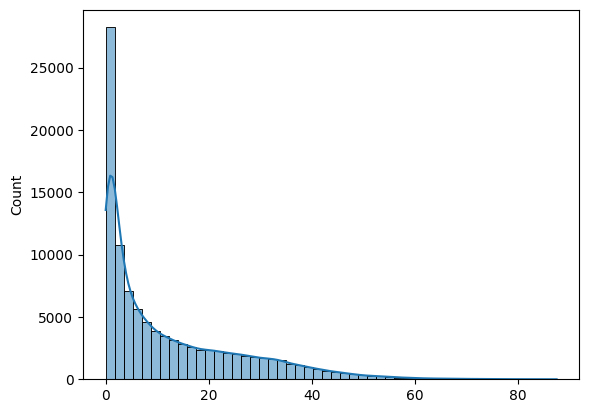

In [ ]:
# This is the first step to generating the 'y' variable in our formulation. 
# Now, we have X (a matrix of risk factors), and each patient's 10 year CVD risk using QRISK3
# This returns a percentage between 0 and 100 - the the probability of a patient having a CVD event in the next 10 years

# Need to confirm that the distribution of risk looks reasonable, 
# and that the relationship between risk and 'y' (CVD event) is as expected 
patient_risk = qrisk3.calculate_qrisk3(patients)

# Perform a sanity check before plotting and generating y 
print("Population Statistics:", patient_risk.describe())
 
# Convert risk scores to numpy array for plotting, outcome sampling and further analysis
risk_pct = patient_risk.to_numpy()

# Plot distribution of risk - should be right skewed 
#TODO: need to fix the x-axis to be between 0 and 100, and add a vertical line at the mean risk
sns.histplot(risk_pct, bins=50, kde=True)

# Display risk as percentages (0-100)
print("Patients risk as percentages (0-100):", risk_pct)

# Simulate the outcomes

In [ ]:
# Bernoulli sampling: 'y' is 1 if a CVD event occurs, otherwise 0 - binary outcome.
# To be used as the training target for model 1. Can the model learn the relationship between 'X' (risk factors), 
# and risk 'y' and therefore learn to predict 'y' from 'X'?

y = simulation.risk_to_event(risk_pct, random_seed=random_seed)

risk_prob = risk_pct / 100 # Recomputed for inspection

# Sanity check: 
# The event rate should be close to the mean calculated risk by QRISK3 
# The mean(y) should be close to the mean(risk_prob) - it checks that the Bernoulli sampling produces the correct ouput
print("Patients risk as predicted probabilities (0-1):", risk_prob[:10])
print("Simulated CVD events (y):", y[:10])

# Show comparisons 
print("Mean risk (%):", risk_pct.mean())
print("Event rate (%):", y.mean() * 100)
print("Event count:", y.sum())


Patients risk as predicted probabilities (0-1): [0.1984309  0.02584981 0.34268645 0.00706148 0.02683983 0.00127737
 0.0332593  0.19451077 0.00709322 0.13689841]
Simulated CVD events (y): [0 0 0 0 0 0 0 0 0 0]
Mean risk (%): 12.071965013907551
Event rate (%): 12.115
Event count: 12115


In [ ]:
# Test the function on a larger sample of patients - n = 10,000

# Sanity check: 
# When scaled the function should give the same event rate as the mean risk percentage from QRISK3.
# The random variation averages out and mean(y) should be very closly matched to mean(risk_prob.
# This connfirms the Bernoulli sompling is producing the correct distribution at scale. 

# Generate larger population and convert into numpy array for analysis
large_patients = simulation.generate_patients(n=10000, random_seed=42)
large_risk_pct= qrisk3.calculate_qrisk3(large_patients).to_numpy()

# Simulate outcomes 
y_large = simulation.risk_to_event(large_risk_pct, random_seed=random_seed)

# Show comparisons
print("Mean risk (%):", large_risk_pct.mean())
print("Event rate (%):", y_large.mean() * 100)
print("Event count:", y_large.sum())

Mean risk (%): 12.077980871939863
Event rate (%): 12.24
Event count: 1224


# Build the feature matrix (M1)

In [ ]:
# Call build_feature_matrix function
X, feature_names = simulation.build_feature_matrix(patients)

# Sanity check:
# The shape of X should be (n_patients, n_features) - n_features is the number of risk factors after one-hot encoding
print("Columns Names:", feature_names)
print("Shape of X:", X.shape)
print("First row of X:", X[0])



Columns Names: ['Age', 'Sex_Female', 'Sex_Male', 'Ethnicity_Bangladeshi', 'Ethnicity_Black African', 'Ethnicity_Black Caribbean', 'Ethnicity_Chinese', 'Ethnicity_Indian', 'Ethnicity_Other Asian', 'Ethnicity_Other Ethnic Group', 'Ethnicity_Pakistani', 'Ethnicity_White', 'Townsend_Score', 'BMI', 'Systolic_Blood_Pressure', 'SD_Systolic_Blood_Pressure', 'Cholesterol_HDL_Ratio', 'Smoking Status_Ex Smoker', 'Smoking Status_Heavy Smoker', 'Smoking Status_Light Smoker', 'Smoking Status_Moderate Smoker', 'Smoking Status_Non-Smoker', 'Type 1 Diabetes', 'Type 2 Diabetes', 'SLE', 'Severe Mental Illness', 'CKD', 'Atrial_Fibrillation', 'Rheumatoid_Arthritis', 'Migraine', 'Erectile_Disfunction', 'Corticosteroids', 'Atypical_Antipsychotics', 'Treated Hypertension', 'Family History of CVD']
Shape of X: (100000, 35)
First row of X: [ 71.           1.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           1.          -0.98769358  24.63       142.9

# Fit a model to predict the risk

We want $y'=f(X)$ to estimate y

TODO: We don't have a test dataset here. We've used the whole `X` and `y` data to fit the model, so we can't evaluate how well it performs on unseen data. We should split our data into a training set and a test set to properly evaluate the model's performance.

In [ ]:
# Call fit_model function

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=random_seed)

model_1 = simulation.fit_model(X_train,y_train)

# Sanity check:
# The predicted event rate should be close to the actual event rate in 'y'; this ensures the model is well calibrated

print("Actual event rate:", y_test.mean())
M_1 = model_1.predict_proba(X_test)[:,1]
print("Model 1 average predicted event rate:", M_1.mean())
# The predicted probabilities of a CVD event outcome for each patient
# It gives a two column array: the probability of the patient belonging to class 0 (no event) and class 1 (event). 
# We only care about the probability of an event - the second column; index 1.


#TODO: Inspect model coefficients to confirm that the model has learned the expected relationships between risk factors and CVD events.
# Does it make biological sense? 
# E.g. Are aga and AF positively associated with CVD risk? Is sex_female negatively associated with CVD risk? 
# Are the relationships in line with existing medical knowledge and literature on CVD risk factors?



Actual event rate: 0.12255
Model 1 average predicted event rate: 0.12179809110011265


## Analyse how good the model is at predicting the risk

### Confusion Matrix - but you need to choose a threshold

This is a bit arbitrary, and it doesn't capture the full picture of the model's performance across all possible thresholds.

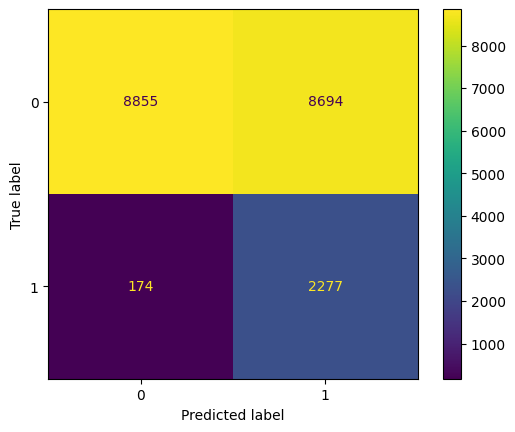

In [ ]:
y_pred_prob = model_1.predict_proba(X_test)[:,1]
threshold = 0.05
metrics.ConfusionMatrixDisplay(
    metrics.confusion_matrix(
        y_true = y_test,
        y_pred = (y_pred_prob > threshold).astype(int)
    )
).plot()


### AUC 

This compares performance across all possible thresholds, and is a good overall measure of how well the model can discriminate between patients who will have an event and those who won't.

AUC-ROC: 0.8175042386999215


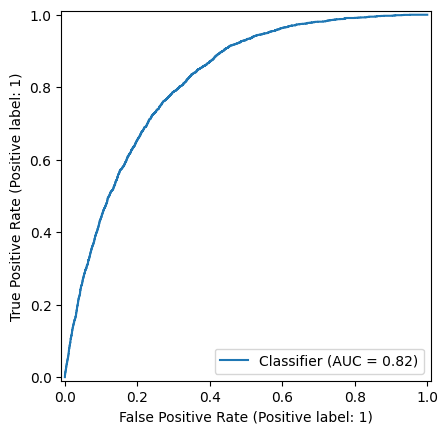

In [ ]:
metrics.RocCurveDisplay.from_predictions(y_test, y_pred_prob)
print("AUC-ROC:", metrics.roc_auc_score(y_test, y_pred_prob))

Violinplot shows the difference in the _scores_ between patients who had an event and those who didn't die. We expect to see higher predicted probabilities for patients who had an event (y=1) compared to those who didn't (y=0). If the model is performing well, the distribution of predicted probabilities for y=1 should be skewed towards higher values, while the distribution for y=0 should be skewed towards lower values.

(0.0, 1.0)

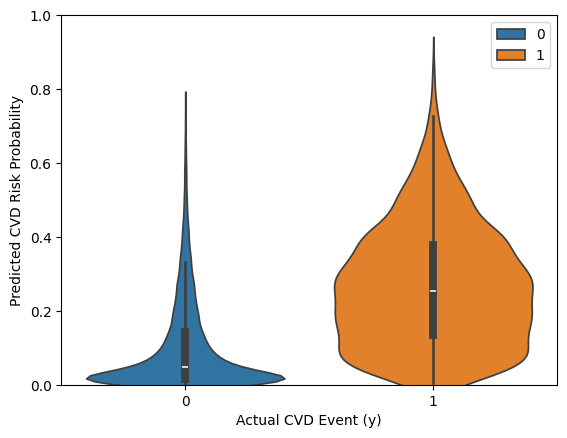

In [ ]:
sns.violinplot(x=y_test, y=y_pred_prob, hue=y_test)
plt.xlabel("Actual CVD Event (y)")
plt.ylabel("Predicted CVD Risk Probability")
plt.ylim(0,1)

Conclusion: Model 1 is OK, possibly could be a bit better. 

Improvements might involve:
* Using a bigger dataset. 
* Using a more complex model (e.g. random forest, gradient boosting, neural network).

# Implement the model a new population and Apply statin intervention

In [ ]:
# Generate a new population. Use a different random seed so we don't get the exact same patients. 
patients_2 = simulation.generate_patients(n_patients, random_seed=random_seed + 1)
display(patients_2)

# Run the full statin intervention function 
X_2, y_2, on_statins, true_risk_b, true_risk_post_b = simulation.apply_statin_intervention(
    patients_2=patients_2,
    model_1=model_1,
    threshold=0.10,
    rrr=0.25,
    random_seed=random_seed + 2,
)
# Sanity check:
# Compare the mean true risk before and after statin intervention. 
statin_checks = [
    ("Fraction of population eligible for statin prescription (%)", on_statins.mean() * 100),
    ("Number of patients on statins (count)", on_statins.sum()),
    ("Population B True CVD Risk (before intervention)", true_risk_b.mean()),
    ("Population B True CVD Risk (after intervention)", true_risk_post_b.mean()),
    ("Untreated Patients True Risk", true_risk_b[~on_statins].mean()),
    ("Treated Patients True Risk (before statins)", true_risk_b[on_statins].mean()),
    ("Treated Patients True Risk (after statins)", true_risk_post_b[on_statins].mean()),
    ("Total CVD Events (count)", y_2.sum()),
    ("Overall Event Eate (%)", y_2.mean() * 100),
    ("Treated Event Rate (%)", y_2[on_statins].mean() * 100),
    ("Untreated Event Rate (%)", y_2[~on_statins].mean() * 100),
]

for label, value in statin_checks:
    print(f"{label}: {value:.2f}")

Age,Sex,Ethnicity,Townsend_Score,BMI,Systolic_Blood_Pressure,SD_Systolic_Blood_Pressure,Cholesterol_HDL_Ratio,Smoking Status,Type 1 Diabetes,Type 2 Diabetes,SLE,Severe Mental Illness,CKD,Atrial_Fibrillation,Rheumatoid_Arthritis,Migraine,Erectile_Disfunction,Corticosteroids,Atypical_Antipsychotics,Treated Hypertension,Family History of CVD
i64,str,str,f64,f64,f64,f64,f64,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
84,"""Male""","""White""",0.57811,31.84,149.55,7.35,3.62,"""Non-Smoker""",0,0,0,0,0,1,0,0,0,0,0,0,1
69,"""Male""","""Indian""",-1.774169,25.93,136.28,1.83,5.24,"""Non-Smoker""",0,0,0,0,0,0,0,0,1,0,0,0,1
41,"""Male""","""White""",-0.674864,28.47,126.08,4.23,4.85,"""Non-Smoker""",0,0,0,0,0,0,0,0,0,0,0,0,0
78,"""Male""","""White""",-7.0,32.89,124.83,5.18,3.99,"""Non-Smoker""",0,0,0,0,1,0,0,0,1,0,0,0,1
36,"""Male""","""White""",-0.345031,25.87,119.55,4.15,3.62,"""Non-Smoker""",0,0,0,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
79,"""Male""","""White""",-2.313104,24.87,145.09,2.46,4.03,"""Non-Smoker""",0,0,0,0,1,0,0,0,1,0,0,0,0
75,"""Male""","""White""",-0.098314,25.68,138.59,1.84,3.31,"""Non-Smoker""",0,1,0,0,0,0,0,0,1,0,0,0,0
42,"""Male""","""White""",-3.529582,26.8,103.49,1.31,5.04,"""Non-Smoker""",0,0,0,0,0,0,0,0,1,0,0,0,0


Fraction of population eligible for statin prescription (%): 39.08
Number of patients on statins (count): 39077.00
Population B True CVD Risk (before intervention): 12.09
Population B True CVD Risk (after intervention): 9.57
Untreated Patients True Risk: 3.27
Treated Patients True Risk (before statins): 25.83
Treated Patients True Risk (after statins): 19.37
Total CVD Events (count): 9553.00
Overall Event Eate (%): 9.55
Treated Event Rate (%): 19.33
Untreated Event Rate (%): 3.28


# Train a new model (M2) on our second population (B). 

Problem: training a model $f_2(x)$ but not accounting for statins.
This is the model-induced concept shift problem. 

In [ ]:
# M2: the model that will be trained to predict CVD events in a new population, after the indtroduction of a statin intervention.
# MAKE SURE THAT MODEL 2 DOESN'T USE THE 'on_statins' COLUMN - IT SHOULDN'T BE A RISK FACTOR IN THE MODEL, IT'S AN INTERVENTION
# We can add this later, but as a first pass, we want the model to be unaware of the intervention, 
# and just see how the coefficients change after the intervention.
# This creates the MICS signal: M2 sees the attenutaed risk associations, 
# because the intervention has weakened the relationship between high-weight risk features and observed events

# Fit M2 on post-intervention outcomes 
model_2 = simulation.fit_model(X_2, y_2)

# Sanity check:
print(f"Observed Event Rate: {y_2.mean():.2%}")
print(f"Model 2 Average Predicted Event Rate: {model_2.predict_proba(X_2)[:, 1].mean():.2%}")

Observed Event Rate: 9.55%
Model 2 Average Predicted Event Rate: 9.56%


## Compare M1 and M2 coefficients - first instance of MICS

In [ ]:
# If MICS is occurring, M2's coefficients on the strong risk factors (AF, T1D, SLE, smoking, age)
# should be smaller in magnitude than M1's. The intervention has reduced the CVD events for high-risk
# patients, so M2 sees a weaker apparent relationship between those features and outcomes.

# Coeffiecient comparison for all features in the model
all_coefficients = simulation.coefficients_comparison(model_1, model_2, feature_names)
display(all_coefficients)

Feature,Model 1 Coefficient,Model 2 Coefficient,Difference (M2 - M1)
str,f64,f64,f64
"""Age""",0.07118,0.059856,-0.011324
"""Sex_Female""",-2.532492,-2.337808,0.194685
"""Sex_Male""",-2.138513,-2.021548,0.116965
"""Ethnicity_Bangladeshi""",-0.049718,-0.091414,-0.041696
"""Ethnicity_Black African""",-1.038889,-0.912537,0.126352
…,…,…,…
"""Erectile_Disfunction""",0.091968,0.11066,0.018692
"""Corticosteroids""",0.320304,0.187892,-0.132412
"""Atypical_Antipsychotics""",0.177665,0.261386,0.083721


In [ ]:
# Subsetting for high-risk features to see if MICS is occurring - are the coefficients smaller in magnitude for M2 than M1?, do we see the expected attenuation of risk factors after the intervention?
high_risk_features = [
    "Age",
    "Atrial_Fibrillation",
    "Type 1 Diabetes",
    "Type 2 Diabetes",
    "SLE",
    "CKD",
    "Smoking Status_Heavy Smoker",
    "Family History of CVD",
]

high_risk_coefficients = all_coefficients.filter(pl.col("Feature").is_in(high_risk_features))
display(high_risk_coefficients)

# TODO: Investigate smoking status - both models show negative coefficient for Heavy Smoker at n=100k.
# Possible causes: (1) reference category issue in one-hot encoding, 
# (2) collinearity with age, (3) sampling structure. 
# Multi-seed runs at n=100k will tell us if this is systematic or noise.


Feature,Model 1 Coefficient,Model 2 Coefficient,Difference (M2 - M1)
str,f64,f64,f64
"""Age""",0.07118,0.059856,-0.011324
"""Smoking Status_Heavy Smoker""",-0.584369,-0.63055,-0.046181
"""Type 1 Diabetes""",1.297144,1.115173,-0.181971
"""Type 2 Diabetes""",0.662168,0.531512,-0.130656
"""SLE""",0.205984,0.224231,0.018247
"""CKD""",0.080982,0.126568,0.045586
"""Atrial_Fibrillation""",0.669662,0.562359,-0.107303
"""Family History of CVD""",0.299845,0.236906,-0.062939


# Generate a comparative third population (C)

In [ ]:
# Independent population for the M1 vs M2 evaluation - do the two modeles give the same predictions for a new population?

# M2 should underpredict risk compared to M1 and the true event rate - it shouldn't be able to account for the fact that there are people on statins 
# This should demonstrate the clinical implications of MICS taking place - as a distinct view that with the depolyment of a miscalibrated model into a new population that has been subject to an intervention (statin prescription) should underperform.
# It's predictive ability should be lower and the coeffiects should deviate more towards zero; bigger negative values for this new third population 

# We are claiming that in this population M2 has the same discrimination (AUC-ROC) as M1, but has worse calibration and underpredicts risk in high-risk patients.

# Generate population C 
patients_3 = simulation.generate_patients(n_patients, random_seed=random_seed + 3)

# Build feature matrix for population C
X_3, feature_names_3 = simulation.build_feature_matrix(patients_3)

# True underlying QRISK3 risk (no interveention)
true_risk_c = qrisk3.calculate_qrisk3(patients_3).to_numpy()

# Generate outcomes for population C based on true underlying risk (no intervention)
y_3 = simulation.risk_to_event(true_risk_c, random_seed=random_seed + 3)

# Produce a score for both models
m1_predicted_risk_c = model_1.predict_proba(X_3)[:, 1]
m2_predicted_risk_c = model_2.predict_proba(X_3)[:, 1]

# Compare mean predicted risk for M1 and M2 against the true risk in population C
print (f"Actual event rate in population C: {y_3.mean() * 100:.2f}%")
print (f"Mean true risk in population C: {true_risk_c.mean():.2f}%")
print (f"Mean predicted risk in population C (M1): {m1_predicted_risk_c.mean() * 100:.2f}%")
print (f"Mean predicted risk in population C (M2): {m2_predicted_risk_c.mean() * 100:.2f}%")


Actual event rate in population C: 12.21%
Mean true risk in population C: 12.17%
Mean predicted risk in population C (M1): 12.20%
Mean predicted risk in population C (M2): 9.62%


In [ ]:
# M1 vs M2 discrimination comparison on Population C - ROC curves and AUC-ROC scores
# Both models' ROC curves on one figure, with AUC-ROC scores in the legend. 
# If MICS keeps discrimination stable, the curves should be similar and nearly overlap, but M2's calibration on the mean will be worse than M1's, 
# and it will underpredict risk in high-risk patients.

plt.figure(figsize=(6, 6))
simulation.plot_roc_curve(y_true=y_3, y_prob=m1_predicted_risk_c,label="Model 1")
simulation.plot_roc_curve(y_true=y_3, y_prob=m2_predicted_risk_c,label="Model 2")
plt.plot([0, 1], [0, 1], color="grey", lw=2, linestyle="--", label="Random Guess (0.5)")
plt.title("ROC Curves: Model 1 vs Model 2 on Population C")
plt.legend(loc="lower right")
plt.show()



NameError: name 'plt' is not defined

<Figure size 600x600 with 0 Axes>

In [ ]:
# TODO:Create a cell in the notebook that has all the variables and the parameters which will be altered and edited for each experiment and iteration of the code. 
# TODO:Create functions for all of the different variables within the notebook - use this current notebook as a schema for running and testing 
# TODO:Clone this notebook and use the new one exclusively for analysis and running all the experiments within it - need to call the functions within. 